# AIoT Project

In [8]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder

# db
import pymongo
from bson import ObjectId

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values
from utils import subtract_mean

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca
from utils_visual import plot_bar
from utils_visual import plot_distribution_analysis

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Start time of execution

In [9]:
time_start = time()

## Load configuration

In [10]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [11]:
axes = config['rename']
print(axes)

['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']


In [12]:
client = pymongo.MongoClient(config["client"])

In [13]:
db = client[config["db"]]
coll = db[config["col"]]

In [14]:
found_keys = coll.distinct("_id")
print(f'Found {len(found_keys)} keys in the collection')

Found 75 keys in the collection


## Load data

In [15]:
# scroll up data
# results = list(coll.find({"gesture_id": "scroll-up-index"}, {"data": True, "gesture_id": True}))
results = list(coll.find({}, {"data": True, "gesture_id": True, 'user': True}))
print(f'Found {len(results)} keys in the collection')

Found 75 keys in the collection


In [16]:
print(results[0].keys())

dict_keys(['_id', 'data', 'gesture_id', 'user'])


In [17]:
def chop_edges_and_concat(results):
    all_chunks = pd.DataFrame(results)
    # print(len(all_chunks))

    ids = all_chunks['gesture_id'].unique().tolist()
    # print(ids)

    gestures = {}
    for id in ids:
        gesture_chunks = all_chunks[all_chunks['gesture_id'] == id]
        print(gesture_chunks.columns)
        current_data = gesture_chunks[['user', 'data']]
        
        chunks = []
        for chunk in current_data.itertuples():
            # print(type(chunk))
            # print(chunk)
            df = pd.DataFrame(chunk.data)
            df.drop(df.tail(500).index, inplace=True)
            df.drop(df.head(500).index, inplace=True)
            df['user'] = chunk.user
            chunks.append((id, df))

        joined_gesture = pd.concat([df for _, df in chunks], ignore_index=True)
        gestures[id] = joined_gesture

        # print(len(chunks[0][1]))
        # print(chunks[0][1].head())

        # print(len(joined_gesture))
        # print(joined_gesture.head())
    return gestures
    
    
# gestures = chop_edges_and_concat(results)
# print(len(gestures))
# print(gestures['scroll-up-index'])


## Cleaning

We Filter for Glitches/Outliers, this also handles missing values by interpolating them

In [18]:
def clean_sensor_outliers(df, window_size=50, threshold=3.0, axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']):
    """
    Cleans extreme hardware spikes using a Rolling Z-Score and Linear Interpolation.
    Assumes 100Hz data (window_size=50 is 0.5 seconds).
    """
    # Create a copy so we don't accidentally overwrite your raw data
    df_clean = df.copy()
    
    # Define your 6 sensor columns from the MetaMotionR IMU
    sensor_columns = axes
    
    for col in sensor_columns:
        # 1. Calculate Rolling Mean and Standard Deviation
        # 'center=True' ensures the window looks at points both before and after the current row
        rolling_mean = df_clean[col].rolling(window=window_size, center=True).mean()
        rolling_std = df_clean[col].rolling(window=window_size, center=True).std()
        
        global_mean = df_clean[col].mean()
        global_std = df_clean[col].std()
        
        # 2. Calculate the Rolling Z-Score
        rolling_z_scores = np.abs((df_clean[col] - rolling_mean) / rolling_std)
        global_scores = np.abs((df_clean[col] - global_mean) / global_std)
        
        # 3. Find how many outliers we are catching (Great for your EDA Report!)
        outlier_count = (rolling_z_scores > threshold).sum()
        # print(f"Cleaned {outlier_count} glitches in {col}")
        
        # 4. Replace those specific outliers with NaN
        df_clean.loc[rolling_z_scores > threshold, col] = np.nan
        df_clean.loc[global_scores > 3.0, col] = np.nan
        
        # 5. Apply Linear Interpolation to smoothly connect the gaps
        # limit_direction='both' ensures it fixes glitches even if they happen on the very first or last row
        df_clean[col] = df_clean[col].interpolate(method='linear', limit_direction='both')
        
    return df_clean


def purge_outliers_all_gestures(gestures, axes=['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z'], window_size=50, threshold=3.0):
    cleaned_gestures = {}
    for gesture_id, gesture_df in gestures.items():
        # print(f'Cleaning gesture: {gesture_id}')
        gesture_cleaned = clean_sensor_outliers(gesture_df, window_size, threshold, axes)
        cleaned_gestures[gesture_id] = gesture_cleaned
    return cleaned_gestures

# cleaned_gestures = purge_outliers_all_gestures(gestures, window_size=50, threshold=2.0)

# Check the first few rows to ensure everything looks correct
# display(cleaned_gestures['scroll-up-index'].head())
# plot_instance_time_domain(gestures['scroll-up-index'])
# plot_instance_time_domain(gestures['scroll-up-index'])
# plot_instance_time_domain(cleaned_gestures['scroll-up-index'])
# plot_instance_time_domain(cleaned_gestures['scroll-up-index'])


In [19]:
# strucure of cleaned_gestures:
# print(type(cleaned_gestures))
# print(cleaned_gestures.keys())
# print(len(cleaned_gestures))
# print(len(cleaned_gestures['scroll-down-index']))
# print(cleaned_gestures['scroll-down-index'])

## Filtering here???? NO>

## Sensor-type grouped scaling

In [20]:

def scale_gestures(gestures_train, gestures_val):
    std_scaler = StandardScaler()
    robust_scaler = RobustScaler()

    all_train_data = pd.concat(gestures_train.values())
    std_scaler.fit(all_train_data[['acc_x', 'acc_y', 'acc_z']])
    robust_scaler.fit(all_train_data[['gyr_x', 'gyr_y', 'gyr_z']])

    for id in gestures_train:
        gestures_train[id][['acc_x', 'acc_y','acc_z']] = std_scaler.transform(gestures_train[id][['acc_x', 'acc_y', 'acc_z']])
        gestures_train[id][['gyr_x', 'gyr_y', 'gyr_z']] = robust_scaler.transform(gestures_train[id][['gyr_x', 'gyr_y', 'gyr_z']])
        
    for id in gestures_val:
        gestures_val[id][['acc_x', 'acc_y', 'acc_z']] = std_scaler.transform(gestures_val[id][['acc_x', 'acc_y', 'acc_z']])
        gestures_val[id][['gyr_x', 'gyr_y', 'gyr_z']] = robust_scaler.transform(gestures_val[id][['gyr_x', 'gyr_y', 'gyr_z']])
    
# scale_gestures(cleaned_gestures, [])
    

## We use sliding widnowing to create our samples

In [26]:
def window_and_filter_gestures(cleaned_gestures, ws=500, overlap=100, order=5, wn=0.4, filter_type='lowpass'):
    clips_arr = []
    clipped_gestures = {}
    for id, data in cleaned_gestures.items():
        # slice data into windows
        filtered_data = data.drop(columns='user').apply(apply_filter, args=(order, wn, filter_type))
        filtered_data['user'] = data['user'] # reattach user so windowing can discard multiple window users
        
        clips = sliding_window_pd(filtered_data, ws=ws, overlap=overlap, print_stats=False)
        total_clips = len(clips)
        # print(f'Total clips: {total_clips}')
        clips_arr.append({'Gesture': id, 'Total Clips': total_clips})
        clipped_gestures[id] = clips
        # print(f'GESTURE_ID: {id}')
        # plot_instance_time_domain(fclips[1], id)
        # plot_instance_3d(fclips[1], axes_list=['gyr_x', 'gyr_y', 'gyr_z'])
        # plot_instance_3d(fclips[1], axes_list=['acc_x', 'acc_y', 'acc_z'])
    return (clipped_gestures, clips_arr)

# Example usage:
# clipped_train, train_distr = window_and_filter_gestures(cleaned_gestures, ws=200, overlap=100, order=5, wn=0.3)

# clipped_train, train_distr = window_and_filter_gestures(cleaned_gestures, ws=200, overlap=50, order=5, wn=0.3, filter_type='lowpass')
# clipped_val, val_distr = window_and_filter_gestures(gestures_val)
# print("clipped_train keys: ", clipped_train.keys(), "\nlength: ", len(clipped_train))
# print("clipped_val keys: ", clipped_val.keys(), "\nlength: ", len(clipped_val))
# print(len(clipped_train['scroll-up-index']), "clips in clipped_train for scroll-up-index")


In [22]:
# bad_windows = 0
# for id, gesture_windows in clipped_train.items():
#     for window in gesture_windows:
#         if window['user'].nunique() > 1:
#             bad_windows += 1
            
# print(f'Bad windows {bad_windows}')

## We flatten each sample 

In [27]:
# print(clipped_gestures.keys())
# print(clipped_train['scroll-down-index'][0])

def flatten_gestures(gesture_clips):
    flattened_clips = {}
    for id, clips in gesture_clips.items():
        flattened_clips[id] = flatten_instances_df(clips)
    return flattened_clips

# train_clips_flattened = flatten_gestures(clipped_train)
# val_clips_flattened = flatten_gestures(clipped_val)

# print(len(train_clips_flattened['scroll-up-index']), "flattened clips in train_clips_flattened for scroll-up-index")    
# print(len(val_clips_flattened['scroll-up-index']), "flattened clips in val_clips_flattened for scroll-up-index")    
# print(train_clips_flattened['scroll-up-index'])

## Classifier - Statistical Learning

### unpack dict data for scikitlearn model

In [24]:
def prepare_xy(flattened_dict):
    X = pd.concat(flattened_dict.values(), ignore_index=True).to_numpy()
    
    y = []
    for gesture_name, df in flattened_dict.items():
        y.extend([gesture_name] * len(df))
        
    return X, np.array(y)

# X_train, y_train = prepare_xy(train_clips_flattened)
# X_val, y_val = prepare_xy(val_clips_flattened)

# print("X_train shape: ", X_train.shape)
# print("Y_train shape: ", y_train.shape)

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder

# --- Extract 3D matrices without flattening ---
def prepare_xy_3d(gesture_clips_dict):
    X_3d = []
    y = []
    for gesture_name, clips in gesture_clips_dict.items():
        for clip in clips:
            if isinstance(clip, pd.DataFrame):
                X_3d.append(clip[['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']].values)
            else:
                X_3d.append(clip)
        y.extend([gesture_name] * len(clips))
    return np.array(X_3d), np.array(y)

# --- Modified CNN Trainer ---
def train_and_predict_cnn(X_train_3d, X_val_3d, y_train, y_val, epochs=20, batch_size=16): 
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_val_encoded = le.transform(y_val)

    ws = X_train_3d.shape[1]
    
    # PyTorch Conv1d expects shape: (Batch, Channels, Length)
    X_train_reshaped = np.transpose(X_train_3d, (0, 2, 1))
    X_val_reshaped = np.transpose(X_val_3d, (0, 2, 1))

    # Convert to Tensors
    train_loader = DataLoader(TensorDataset(
        torch.tensor(X_train_reshaped, dtype=torch.float32), 
        torch.tensor(y_train_encoded, dtype=torch.long)
    ), batch_size=batch_size, shuffle=True)
    
    val_loader = DataLoader(TensorDataset(
        torch.tensor(X_val_reshaped, dtype=torch.float32), 
        torch.tensor(y_val_encoded, dtype=torch.long)
    ), batch_size=batch_size, shuffle=False)

    # Model Definition
    class GestureCNN(nn.Module):
        def __init__(self, num_classes, ws):
            super(GestureCNN, self).__init__()
            self.conv_block = nn.Sequential(
                nn.Conv1d(6, 16, kernel_size=5, stride=1, padding=2),
                nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(4), nn.Dropout(0.2),
                nn.Conv1d(16, 32, kernel_size=5, stride=1, padding=2),
                nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(5), nn.Dropout(0.2)
            )
            self.fc_block = nn.Sequential(
                nn.Flatten(),
                nn.Linear(32 * (ws // 4 // 5), 64),
                nn.ReLU(), nn.Dropout(0.6),
                nn.Linear(64, num_classes)
            )

        def forward(self, x):
            return self.fc_block(self.conv_block(x))

    model = GestureCNN(len(le.classes_), ws)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-3)

    # Train Silently
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            
    # Predict
    model.eval()
    all_preds = []
    with torch.no_grad():
        for val_X, _ in val_loader:
            _, predicted = torch.max(model(val_X), 1)
            all_preds.extend(predicted.cpu().numpy())

    # Return string labels to match Random Forest
    return le.inverse_transform(all_preds)

In [32]:
def process_fold(gestures_train, gestures_val):
    # Scaling
    scale_gestures(gestures_train, gestures_val)
    
    # Windowing and Filtering
    clipped_train, _ = window_and_filter_gestures(gestures_train, ws=200, overlap=50, order=5, wn=0.4, filter_type='lowpass')
    clipped_val, _ = window_and_filter_gestures(gestures_val, ws=200, overlap=50, order=5, wn=0.4, filter_type='lowpass')
    
    # -----------------------------------------------
    # MODEL 1: Random Forest on Flattened Data
    # -----------------------------------------------
    train_clips_flat = flatten_gestures(clipped_train)
    val_clips_flat = flatten_gestures(clipped_val)
    
    X_train_flat, y_train_flat = prepare_xy(train_clips_flat)
    X_val_flat, y_val = prepare_xy(val_clips_flat) # y_val is the same for both models
    
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train_flat, y_train_flat)
    y_preds_rf = rf_model.predict(X_val_flat)
    
    # -----------------------------------------------
    # MODEL 2: 1D CNN on Raw 3D Data
    # -----------------------------------------------
    X_train_3d, y_train_3d = prepare_xy_3d(clipped_train)
    X_val_3d, y_val_3d = prepare_xy_3d(clipped_val)
    
    y_preds_cnn = train_and_predict_cnn(X_train_3d, X_val_3d, y_train_3d, y_val_3d)
    
    # Return both predictions
    fold_predictions = {
        "Random Forest (Flattened Base)": y_preds_rf,
        "1D CNN (Raw Windows)": y_preds_cnn
    }
    
    return y_val, fold_predictions

## Standard K Fold

In [33]:
from sklearn.model_selection import KFold

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=False)

# default cleaning
gestures = chop_edges_and_concat(results)
cleaned_gestures = purge_outliers_all_gestures(gestures)

all_y_true = []
all_y_pred = {
    "Random Forest (Flattened Base)": [],
    "1D CNN (Raw Windows)": []
}

for fold in range(n_splits):
    print(f"\n--- Running Fold: {fold + 1}/{n_splits} ---")
    
    fold_train, fold_val = {}, {}
    
    # Split the continuous data chronologically
    for gid, df in cleaned_gestures.items():
        train_dfs, val_dfs = [], []
        for user in df['user'].unique():
            user_df = df[df['user'] == user]
            splits = list(kf.split(user_df))
            train_idx, val_idx = splits[fold]
            train_dfs.append(user_df.iloc[train_idx])
            val_dfs.append(user_df.iloc[val_idx])
            
        fold_train[gid] = pd.concat(train_dfs).copy()
        fold_val[gid] = pd.concat(val_dfs).copy()
        
    # Run Both Models
    y_val_true, fold_preds = process_fold(fold_train, fold_val)
    
    # Store Results
    all_y_true.extend(y_val_true)
    for model_name in all_y_pred.keys():
        all_y_pred[model_name].extend(fold_preds[model_name])
        
print("\nDeep Learning vs Classical CV Complete!")

Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')

--- Running Fold: 1/5 ---

--- Running Fold: 2/5 ---

--- Running Fold: 3/5 ---

--- Running Fold: 4/5 ---

--- Running Fold: 5/5 ---

Deep Learning vs Classical CV Complete!


🏆 K-FOLD HEAD-TO-HEAD RESULTS

---> RANDOM FOREST (FLATTENED BASE) <---
                   precision    recall  f1-score   support

scroll-down-index       0.74      0.80      0.77      1686
  scroll-up-index       0.74      0.72      0.73      1700
 swipe-left-index       0.79      0.88      0.83      1705
swipe-right-index       0.63      0.57      0.60      1755
   texting-single       0.97      0.91      0.94      1680

         accuracy                           0.77      8526
        macro avg       0.77      0.78      0.77      8526
     weighted avg       0.77      0.77      0.77      8526


---> 1D CNN (RAW WINDOWS) <---
                   precision    recall  f1-score   support

scroll-down-index       0.89      0.95      0.92      1686
  scroll-up-index       0.85      0.90      0.88      1700
 swipe-left-index       0.89      0.91      0.90      1705
swipe-right-index       0.88      0.79      0.83      1755
   texting-single       1.00      0.93      0.96      1680

      

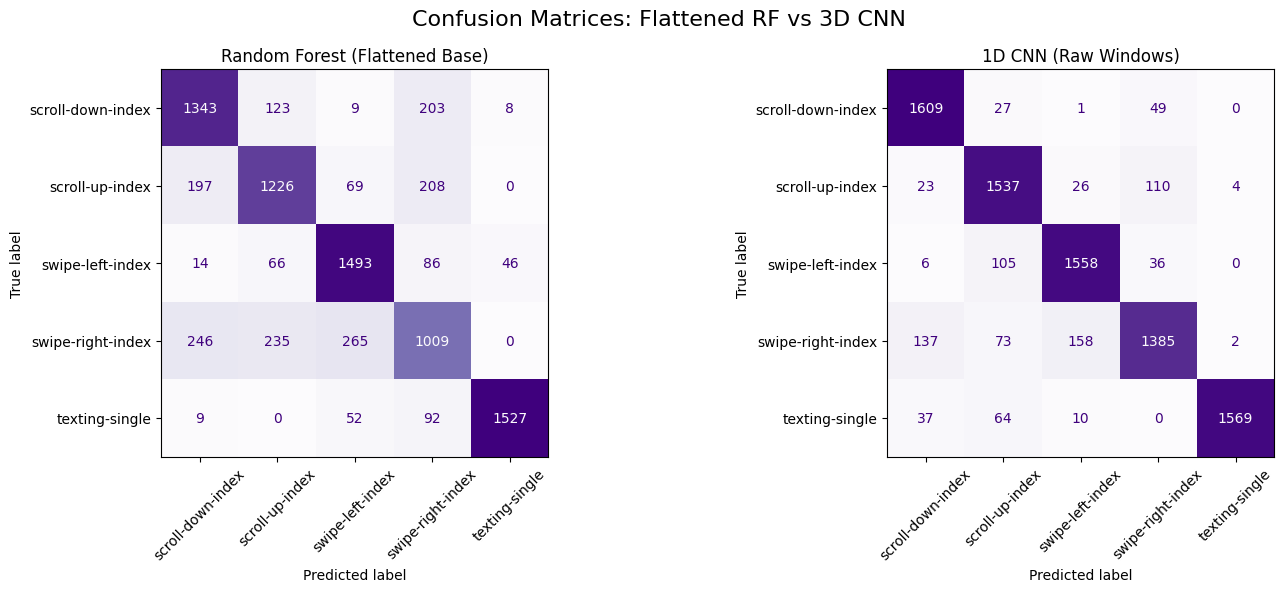

In [34]:
print("="*60)
print("🏆 K-FOLD HEAD-TO-HEAD RESULTS")
print("="*60)

for model_name, y_pred in all_y_pred.items():
    print(f"\n---> {model_name.upper()} <---")
    print(classification_report(all_y_true, y_pred, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Confusion Matrices: Flattened RF vs 3D CNN', fontsize=16)

for ax, (model_name, y_pred) in zip(axes, all_y_pred.items()):
    ConfusionMatrixDisplay.from_predictions(
        all_y_true, y_pred, ax=ax, cmap='Purples', colorbar=False, xticks_rotation=45
    )
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

## Leave One Subject Out Cross Validation LOSO-CV

In [ ]:
unique_users = ['01', '02', '03']
classification_results = {}
print(axes)

# default cleaning
gestures = chop_edges_and_concat(results)
# clean_nans(gestures)
cleaned_gestures = purge_outliers_all_gestures(gestures, axes=['acc_x', 'acc_y', 'acc_z'])

for holdout_user in unique_users:
    print(f"--- Running Fold: User {holdout_user} is Validation ---")
    
    fold_train = {gid: df[df['user'] != holdout_user].copy() for gid, df in cleaned_gestures.items()}
    fold_val = {gid: df[df['user'] == holdout_user].copy() for gid, df in cleaned_gestures.items()}
    
    y_true, y_pred = process_fold(fold_train, fold_val)
    
    classification_results[holdout_user] = {'true': y_true, 'pred': y_pred}
    
        

# print("gestures_train keys: ", gestures_train.keys(), "\nlength: ", len(gestures_train))
# print("gestures_val keys: ", gestures_val.keys(), "\nlength: ", len(gestures_val))
# print("Example X_train shape: ", gestures_train['scroll-up-index'])

['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Cleaning gesture: scroll-down-index
Cleaned 167 glitches in acc_x
Cleaned 37 glitches in acc_y
Cleaned 50 glitches in acc_z
Cleaning gesture: scroll-up-index
Cleaned 109 glitches in acc_x
Cleaned 20 glitches in acc_y
Cleaned 33 glitches in acc_z
Cleaning gesture: texting-single
Cleaned 562 glitches in acc_x
Cleaned 478 glitches in acc_y
Cleaned 168 glitches in acc_z
Cleaning gesture: swipe-right-index
Cleaned 132 glitches in acc_x
Cleaned 42 glitches in acc_y
Cleaned 156 glitches in acc_z
Cleaning gesture: swipe-left-index
Cleaned 93 glitches in acc_x
Cleaned 15 glitches in acc_y
Cleaned 41 glitches in acc_z
--- Running Fold: User 01 is Validation

## K FOLD RESULTS

FINAL LOSO-CV RESULTS:
                   precision    recall  f1-score   support

scroll-down-index       0.33      1.00      0.50       570
  scroll-up-index       0.00      0.00      0.00       608
 swipe-left-index       0.00      0.00      0.00       595
swipe-right-index       0.30      0.29      0.30       575
   texting-single       0.88      1.00      0.94       567

         accuracy                           0.45      2915
        macro avg       0.30      0.46      0.35      2915
     weighted avg       0.30      0.45      0.34      2915



/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

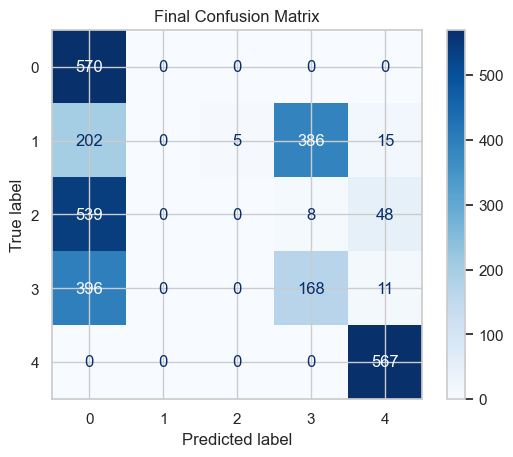

In [20]:
# we combina all fold results
final_true = np.concatenate([res['true'] for res in classification_results.values()])
final_pred = np.concatenate([res['pred'] for res in classification_results.values()])

print("FINAL LOSO-CV RESULTS:")
print(classification_report(final_true, final_pred))
conf_matrix = confusion_matrix(final_true, final_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp_rf.plot(cmap=plt.cm.Blues)
plt.title("Final Confusion Matrix")
plt.show()

### Evaluate classifiers

### Apply optimization with Grid Search and/or Cross-validation

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

### Evaluate optimized classifier